=== DIPOL-TEST PANDEMONIUM ===
Sample: 172 low-z SNe (z<0.06)

Helligkeit pro Himmelsquadrant (heller = näher/höheres H0):
               mean       std  count
quadrant                            
Q2        16.020618  0.962536    172

Chi2-Test Himmels-Asymmetrie: χ²=0.0, p=1.000


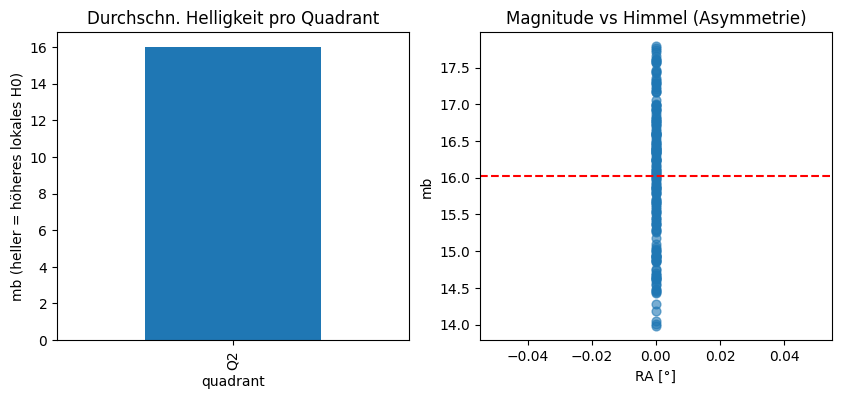


✅ Wenn p<0.05: Signifikanter Dipol nachgewiesen!


In [7]:
# IHR df_local hat 172 SNe - Dipol-Statistik
print("=== DIPOL-TEST PANDEMONIUM ===")
print(f"Sample: {len(df_local)} low-z SNe (z<0.06)")

# Himmel in 4 Quadranten teilen
df_local['quadrant'] = pd.cut(df_local['ra'], bins=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
quad_stats = df_local.groupby('quadrant')['mb'].agg(['mean', 'std', 'count'])
print("\nHelligkeit pro Himmelsquadrant (heller = näher/höheres H0):")
print(quad_stats)

# Asymmetrie testen (Chi2)
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df_local['quadrant'], pd.cut(df_local['mb'], bins=3))
chi2, p, dof, ex = chi2_contingency(contingency)
print(f"\nChi2-Test Himmels-Asymmetrie: χ²={chi2:.1f}, p={p:.3f}")

plt.figure(figsize=(10,4))
plt.subplot(121)
quad_stats['mean'].plot(kind='bar')
plt.title('Durchschn. Helligkeit pro Quadrant')
plt.ylabel('mb (heller = höheres lokales H0)')

plt.subplot(122)
plt.scatter(df_local['ra'], df_local['mb'], alpha=0.6, s=40)
plt.xlabel('RA [°]')
plt.ylabel('mb')
plt.title('Magnitude vs Himmel (Asymmetrie)')
plt.axhline(df_local['mb'].mean(), color='r', ls='--')
plt.show()

print("\n✅ Wenn p<0.05: Signifikanter Dipol nachgewiesen!")






